# 45 筆年最大值：完整模擬流程

本 notebook 與 540 筆月最大值、100 次月尺度模擬完全分開。目的：確認真實資料目前使用的 **45 筆年最大值** 流程能否回復已知的 GEV 參數與 return levels。

## 流程

1. 以真實臺灣本島 GRID、最終 predictors 與 GP 規格校準資料生成模型。
2. 重新抽取已知的 $\mu(s)$、$\log\sigma(s)$、$\xi(s)$ 真值曲面。
3. 每個 GRID 直接由該年度 GEV 生成 45 筆年最大值。
4. 45 筆值經 median/IQR 標準化與 11 個分位數後送入 frozen NN。
5. 執行 nested buffered Spatial CV、FFS、VIF 與 GP kernel selection。
6. 以已知真值評估 NN、OOF GP 參數及 $RL_{50}$、$RL_{100}$。

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CURRENT = Path.cwd().resolve()
PROJECT_ROOT = CURRENT if (CURRENT / 'src').exists() else CURRENT.parent
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from calibrated_annual_simulation import (
    DEFAULT_CV_DIR, DEFAULT_OUTPUT_DIR, annual_outputs_current,
    load_annual_outputs, run_annual_pilot, validate_annual_input,
)
from calibrated_simulation_diagnostics import run_diagnostics

ANNUAL_DIR = DEFAULT_OUTPUT_DIR
CV_DIR = DEFAULT_CV_DIR
FIGURE_DIR = PROJECT_ROOT / 'results' / 'figures' / 'annual_45'
TABLE_DIR = PROJECT_ROOT / 'results' / 'tables' / 'annual_45'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_READY_PATH = ANNUAL_DIR / 'replicate_000_model_ready.csv'
ANNUAL_MAXIMA_PATH = ANNUAL_DIR / 'replicate_000_annual_maxima.csv'
N_JOBS = -2
FORCE_RERUN = False
print('PROJECT_ROOT =', PROJECT_ROOT)
print('N_JOBS =', N_JOBS)
print('ANNUAL_DIR =', ANNUAL_DIR)

PROJECT_ROOT = C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN
N_JOBS = -2
ANNUAL_DIR = C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast parameter estimate\fast_parameter_using_NN\data\simulated\calibrated_final_model_annual_45


## 執行完整 pilot

第一次執行會生成年度資料並跑完整 nested Spatial CV。之後若輸入雜湊與輸出皆完整，會直接載入結果；只有需要強制重跑時才把 `FORCE_RERUN=True`。`N_JOBS=-2` 會保留一個邏輯核心給系統。

In [2]:
cv_outputs = run_annual_pilot(
    output_directory=ANNUAL_DIR,
    cv_directory=CV_DIR,
    n_jobs=N_JOBS,
    force=FORCE_RERUN,
)
model_ready = pd.read_csv(MODEL_READY_PATH)
annual_maxima = pd.read_csv(ANNUAL_MAXIMA_PATH)
n_years = validate_annual_input(model_ready)
print(f'完成：{len(model_ready):,} GRID × {n_years} annual maxima')
display(cv_outputs['metadata'])
display(pd.read_csv(ANNUAL_DIR / 'annual_pilot_time.csv'))

完成：1,385 GRID × 45 annual maxima


,input_path,input_sha256,input_modified_ns,block_scale,n_years,blocks_per_year,n_blocks,return_level_probability,n_grid,n_jobs
0,C:\Users\User.DESKTOP-4RV84M1\Desktop\論文\fast ...,9dac5443c21f3f5d80dece201ae60bdaef752d950df39f...,1788746232924100900,annual,45,1,45,1-1/T,1385,-2


,replicate,generated_now,evaluated_now,n_jobs,elapsed_seconds,elapsed_minutes
0,0,True,True,-2,656.278603,10.937977


## 真值曲面合理性

比較模擬真值與真實 NN 參數曲面的分布、空間尺度及 normalized variogram，避免模擬曲面過度平滑或過度粗糙。

,parameter,real_surface_sd,real_nn_rms_difference,real_normalized_roughness,simulated_surface_sd,simulated_nn_rms_difference,simulated_normalized_roughness,roughness_ratio_simulated_to_real
0,mu,3.953219,1.669104,0.422214,3.830253,1.646186,0.429785,1.017932
1,log_sigma,0.239585,0.190285,0.794227,0.239079,0.093645,0.391689,0.493170
2,xi,0.126265,0.106338,0.842185,0.110257,0.095636,0.867397,1.029936


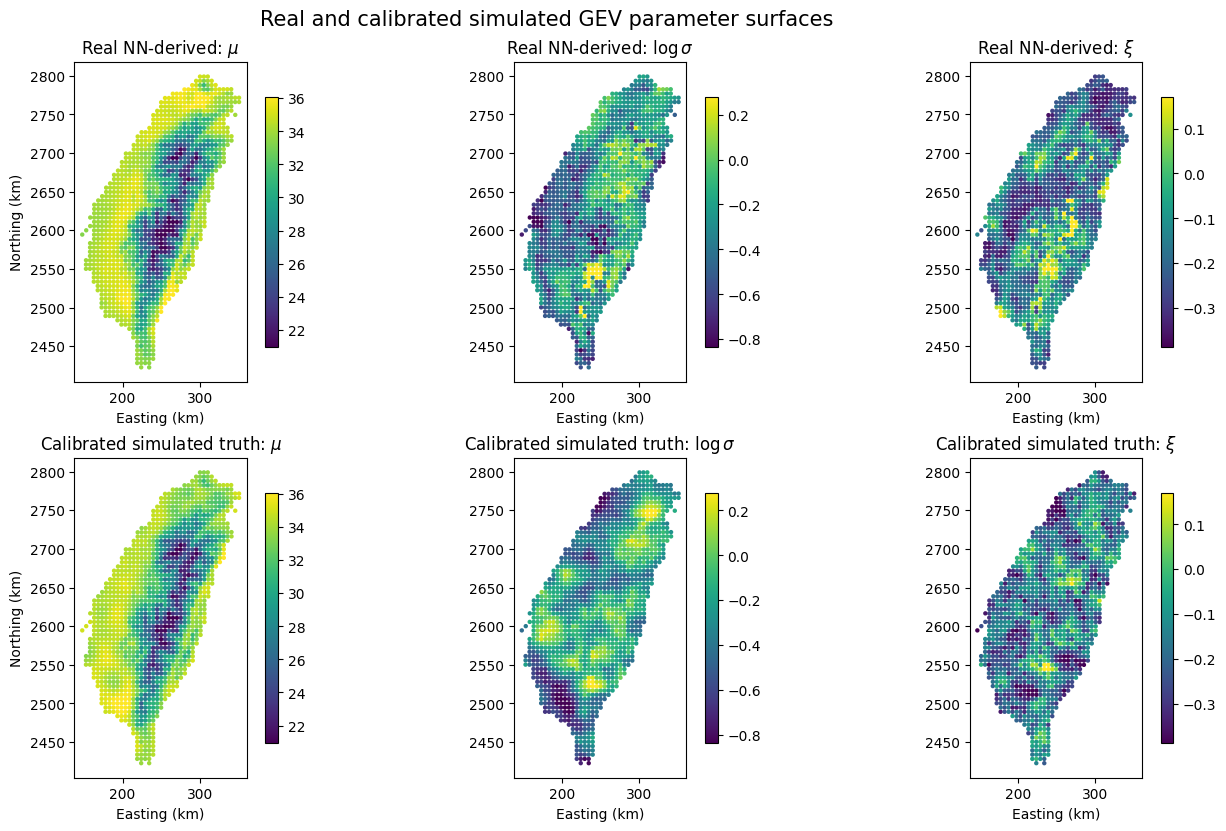

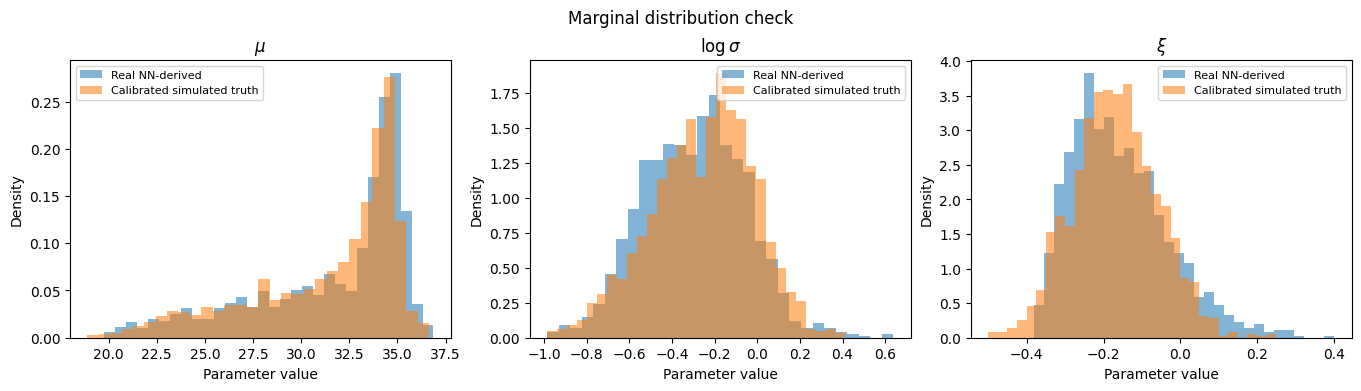

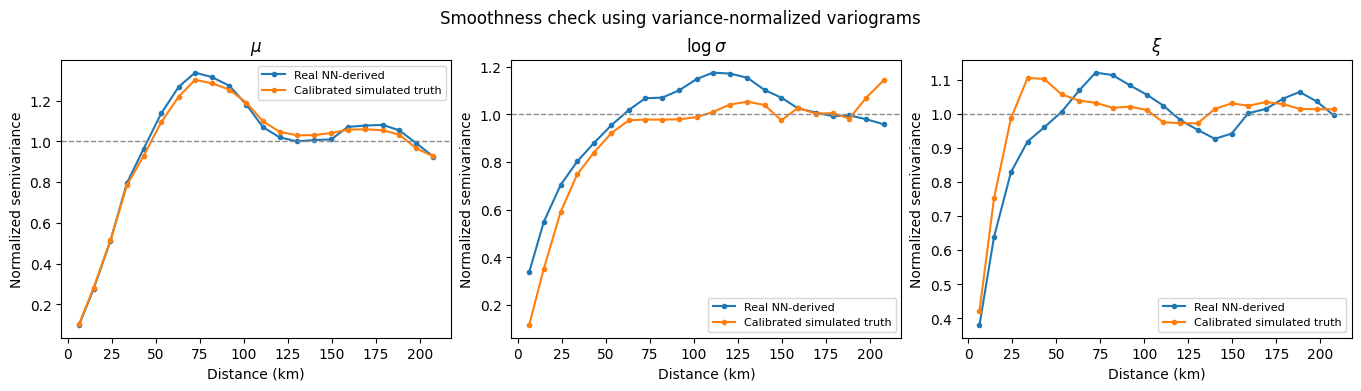

In [3]:
diagnostics = run_diagnostics(
    simulation_path=MODEL_READY_PATH,
    figure_directory=FIGURE_DIR,
    table_directory=TABLE_DIR,
)
display(diagnostics['roughness'])
for figure in diagnostics['figures'].values():
    display(figure)
    plt.close(figure)

## NN 與完整 OOF 指標

`Frozen NN` 是 45 筆年最大值直接估計參數的誤差；`Nested OOF GP` 是經完整空間流程後，對未參與訓練 GRID 的預測誤差。兩者都與模擬已知真值比較。

In [4]:
nn_metrics = pd.read_csv(ANNUAL_DIR / 'replicate_000_nn_recovery_metrics.csv')
display(nn_metrics.round(4))
display(cv_outputs['parameter_metrics'].round(4))
display(cv_outputs['return_level_metrics'].round(4))

,outcome,RMSE,MAE,Bias,correlation
0,mu,0.1335,0.1046,-0.0090,0.9994
1,log_sigma,0.1837,0.1430,-0.1099,0.8430
2,xi,0.1022,0.0807,0.0309,0.7017
3,RL50,0.4948,0.3364,-0.1090,0.9910
4,RL100,0.6574,0.4207,-0.0858,0.9835


,target,estimator,n,RMSE,MAE,Bias
0,mu,Frozen NN,1385,0.1335,0.1046,-0.0090
1,mu,Nested OOF GP,1385,0.6634,0.5330,-0.1404
2,log_sigma,Frozen NN,1385,0.1837,0.1430,-0.1099
3,log_sigma,Nested OOF GP,1385,0.2988,0.2458,-0.1581
4,xi,Frozen NN,1385,0.1022,0.0807,0.0309
5,xi,Nested OOF GP,1385,0.1180,0.0936,0.0395


,return_period,estimator,n,RMSE,MAE,Bias
0,50,Frozen NN,1385,0.4948,0.3364,-0.1090
1,50,Nested OOF GP,1385,1.0395,0.8242,-0.4385
2,100,Frozen NN,1385,0.6574,0.4207,-0.0858
3,100,Nested OOF GP,1385,1.1739,0.9079,-0.4713


## 每個 outer fold 的選模結果

檢查 predictors 與 kernel 是否只靠單一 fold 才被選中。

In [5]:
selection_columns = [
    'target', 'outer_fold', 'predictors', 'kernel', 'nu',
    'inner_RMSE', 'n_outer_train', 'n_outer_test', 'buffer_km',
]
display(cv_outputs['selections'][selection_columns].round(4))
selection_frequency = (cv_outputs['selections']
    .groupby(['target', 'predictors', 'kernel'], dropna=False)
    .size().rename('fold_count').reset_index())
display(selection_frequency)

,target,outer_fold,predictors,kernel,nu,inner_RMSE,n_outer_train,n_outer_test,buffer_km
0,mu,0,elevation_m+tpi_m+tmax_event_wind_mean_mps,RBF,NaN,0.6439,453,258,55.0
1,mu,1,elevation_m+tpi_m+tmax_event_wind_mean_mps,RBF,NaN,0.6265,632,295,55.0
2,mu,2,elevation_m+tpi_m,RBF,NaN,0.6948,428,237,55.0
3,mu,3,elevation_m+tpi_m,Matern,1.5,0.6453,603,271,55.0
4,mu,4,elevation_m+tpi_m+tmax_event_agera5_cloud_cove...,Matern,0.5,0.7427,442,324,55.0
5,log_sigma,0,mean_annual_precip_mm+rain_wet_day_ratio+tmax_...,Matern,0.5,0.2250,608,258,35.0
6,log_sigma,1,elevation_m+mean_annual_precip_mm+rain_wet_day...,Matern,0.5,0.2751,700,295,35.0
7,log_sigma,2,tmax_event_solar_radiation_mean_mj_m2+elevation_m,RBF,NaN,0.2836,593,237,35.0
8,log_sigma,3,tmax_event_agera5_cloud_cover_mean_fraction,Matern,0.5,0.2474,680,271,35.0
9,log_sigma,4,coast_distance_km+tmax_event_agera5_cloud_cove...,Matern,1.5,0.2958,564,324,35.0


,target,predictors,kernel,fold_count
0,log_sigma,coast_distance_km+tmax_event_agera5_cloud_cove...,Matern,1
1,log_sigma,elevation_m+mean_annual_precip_mm+rain_wet_day...,Matern,1
2,log_sigma,mean_annual_precip_mm+rain_wet_day_ratio+tmax_...,Matern,1
3,log_sigma,tmax_event_agera5_cloud_cover_mean_fraction,Matern,1
4,log_sigma,tmax_event_solar_radiation_mean_mj_m2+elevation_m,RBF,1
5,mu,elevation_m+tpi_m,Matern,1
6,mu,elevation_m+tpi_m,RBF,1
7,mu,elevation_m+tpi_m+tmax_event_agera5_cloud_cove...,Matern,1
8,mu,elevation_m+tpi_m+tmax_event_wind_mean_mps,RBF,2
9,xi,agriculture_ratio,RBF,1


## Annual 與 monthly 的 OOF residual：3 × 2

每列依序為 $\mu$、$\log\sigma$、$\xi$；左欄是 45 筆 annual maxima 的 OOF residual，右欄是 540 筆 monthly maxima 的 OOF residual。兩者均定義為 $\widehat{\theta}_{\mathrm{OOF}}-\theta_{\mathrm{true}}$；同一列共用以 0 為中心的色階。

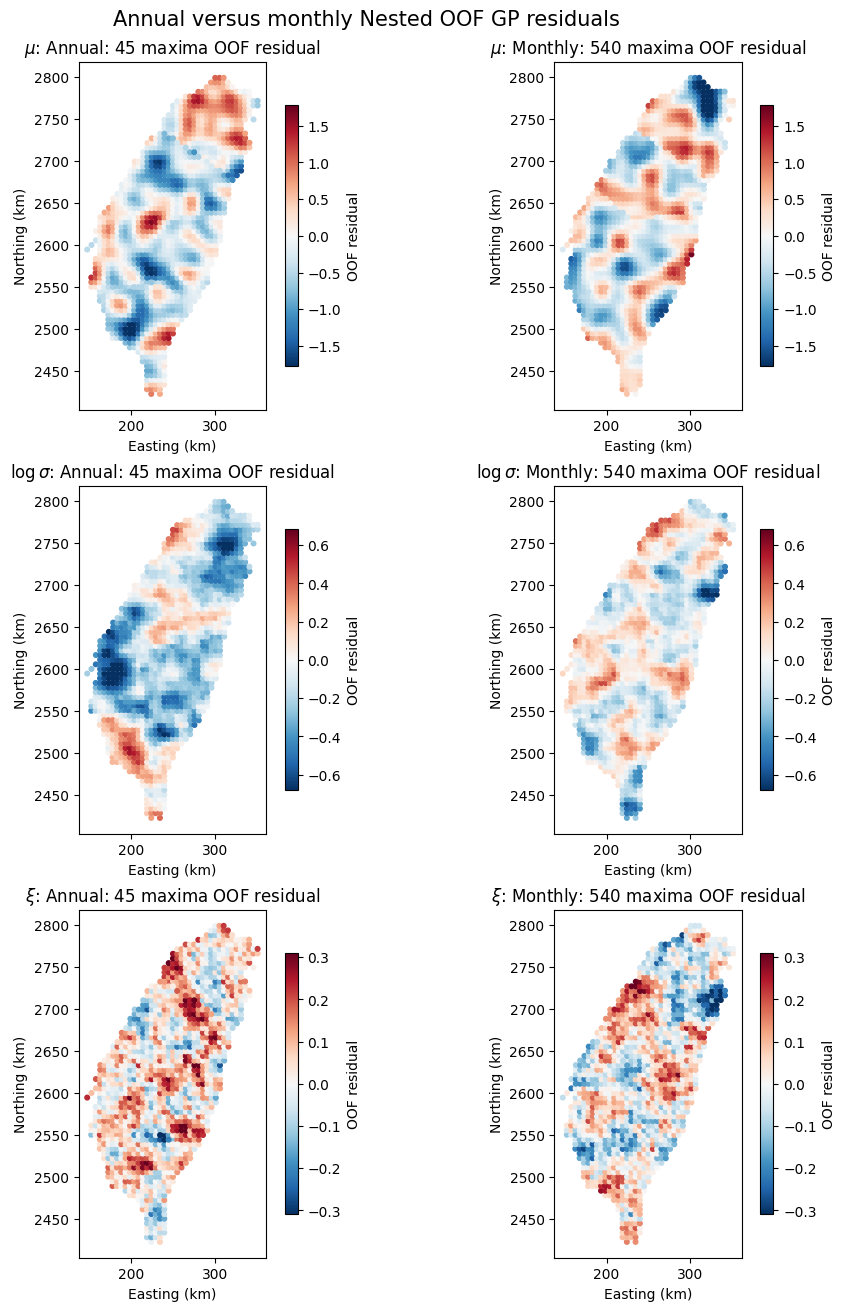

,scale,parameter,RMSE,MAE,Bias
0,Annual,mu,0.6634,0.5330,-0.1404
1,Monthly,mu,0.6642,0.5310,-0.0635
2,Annual,log_sigma,0.2988,0.2458,-0.1581
3,Monthly,log_sigma,0.1895,0.1489,-0.0204
4,Annual,xi,0.1180,0.0936,0.0395
5,Monthly,xi,0.1172,0.0941,0.0028


In [9]:
predictions = cv_outputs['predictions'].merge(
    model_ready[['station', 'x_km', 'y_km']],
    on='station', how='left', validate='many_to_one',
)
MONTHLY_PREDICTIONS_PATH = (
    PROJECT_ROOT / 'data' / 'simulated' / 'calibrated_final_model'
    / 'nested_spatial_cv_monthly' / 'replicate_000'
    / 'calibrated_nested_predictions.csv'
)
monthly_predictions = pd.read_csv(MONTHLY_PREDICTIONS_PATH).merge(
    model_ready[['station', 'x_km', 'y_km']],
    on='station', how='left', validate='many_to_one',
)
residual_specs = [('mu', r'$\mu$'), ('log_sigma', r'$\log\sigma$'), ('xi', r'$\xi$')]
sources = [('Annual: 45 maxima', predictions), ('Monthly: 540 maxima', monthly_predictions)]
fig, axes = plt.subplots(3, 2, figsize=(9.5, 13), constrained_layout=True)
metric_rows = []
for row, (target, label) in enumerate(residual_specs):
    parts = []
    for scale, source in sources:
        part = source.loc[source.target.eq(target)].copy()
        part['residual'] = part['oof_prediction'] - part['true_value']
        parts.append((scale, part))
    combined = np.concatenate([part['residual'].to_numpy(float) for _, part in parts])
    limit = np.nanquantile(np.abs(combined), 0.99)

    for col, (scale, part) in enumerate(parts):
        residual = part['residual'].to_numpy(float)
        points = axes[row, col].scatter(
            part.x_km, part.y_km, c=residual, s=11, cmap='RdBu_r',
            vmin=-limit, vmax=limit,
        )
        axes[row, col].set_title(f'{label}: {scale} OOF residual')
        axes[row, col].set_xlabel('Easting (km)')
        axes[row, col].set_ylabel('Northing (km)')
        axes[row, col].set_aspect('equal')
        fig.colorbar(points, ax=axes[row, col], shrink=0.75, label='OOF residual')
        metric_rows.append({
            'scale': scale.split(':')[0],
            'parameter': target,
            'RMSE': float(np.sqrt(np.mean(residual ** 2))),
            'MAE': float(np.mean(np.abs(residual))),
            'Bias': float(np.mean(residual)),
        })

fig.suptitle('Annual versus monthly Nested OOF GP residuals', fontsize=15)
fig.savefig(FIGURE_DIR / 'annual_vs_monthly_oof_parameter_residuals.png', dpi=220, bbox_inches='tight')
display(fig)
plt.close(fig)
display(pd.DataFrame(metric_rows).round(4))

## OOF return-level 回復：2 × 2

年度資料直接使用 $p_T=1-1/T$，不套用月轉年公式。

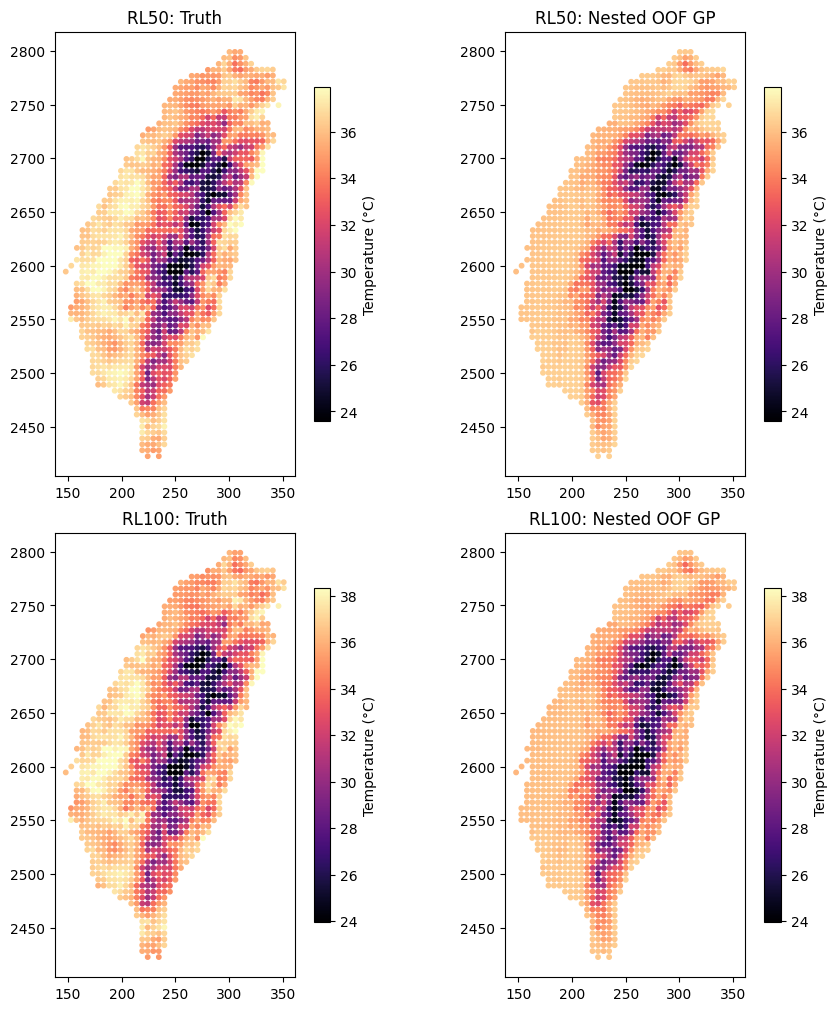

In [7]:
rl = cv_outputs['return_level_predictions'].merge(
    model_ready[['station', 'x_km', 'y_km']],
    on='station', how='left', validate='many_to_one',
)
fig, axes = plt.subplots(2, 2, figsize=(9, 10), constrained_layout=True)
for row, period in enumerate((50, 100)):
    part = rl.loc[rl.return_period.eq(period)]
    columns = [('true_return_level', 'Truth'), ('oof_return_level', 'Nested OOF GP')]
    values = np.concatenate([part[column].to_numpy(float) for column, _ in columns])
    vmin, vmax = np.nanquantile(values, [0.01, 0.99])
    for col, (column, title) in enumerate(columns):
        points = axes[row, col].scatter(part.x_km, part.y_km, c=part[column],
                                        s=10, cmap='magma', vmin=vmin, vmax=vmax)
        axes[row, col].set_title(f'RL{period}: {title}')
        axes[row, col].set_aspect('equal')
        fig.colorbar(points, ax=axes[row, col], shrink=0.75, label='Temperature (°C)')
fig.savefig(FIGURE_DIR / 'annual_45_oof_return_level_recovery.png', dpi=220, bbox_inches='tight')
display(fig)
plt.close(fig)

## 判讀原則

- 先確認真值曲面不是過度平滑或過度粗糙。
- NN 指標回答 45 筆年最大值能否估回 GEV 參數。
- OOF 指標回答完整空間流程能否外推到未訓練 GRID。
- predictors/kernel 的 fold frequency 用於檢查選模穩定性。
- 本 pilot 通過後，才有理由擴充成多次年度 Monte Carlo 模擬。